In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode
# function_collection import *

In [2]:
# parameters
region_level = "nuts4"
year = 2017

**Figure 1 - MNEs in Hungary**

In [37]:
# load industry-region level MNE tables -- original table "../data/oc01_2022_november/mne_share_nace3d_jaras.csv"
mne_df = pd.read_csv(f"../outputs/mne_share_nace3d_{region_level}.csv", sep=";", index_col=0)

# load map shapes
region_gdf = gpd.read_file(f"../data/shape_files/{region_level}_shape.geojson")

# region names -- original table "../data/oc01_2022_november/region_codes.csv"
key_table = pd.read_csv("../outputs/region_names_codes.csv", sep=";")

In [38]:
# prepare key_table and join to regions shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_name"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [39]:
# aggregate MNE data
def aggregate_mne_table(df, focus=None):
    if focus == "manufacturing":
        df = df[(df["nace3d"] >= 100) & (mne_df["nace3d"] <= 350)]
    if focus == "services":
        "print -- update service nace code range!"
    
    group_col = str(region_level) + "_code"

    agg_table = df.groupby(group_col)\
        .agg(
            nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
            nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
            mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
            total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
        ).reset_index()

    agg_table["mne_firm_share"] = agg_table["nr_mnes"] / agg_table["nr_firms"]
    agg_table["mne_emp_share"] = agg_table["mne_emp"] / agg_table["total_emp"]
    
    return agg_table

# aggregate_mne_table(mne_df, focus="manufacturing")
region_mne_df = aggregate_mne_table(mne_df)

In [40]:
# merge MNE data to shape
key_column = str(region_level) + "_code"
plot_df = pd.merge(
    plot_df,
    region_mne_df,
    on=key_column,
    how="left"
)

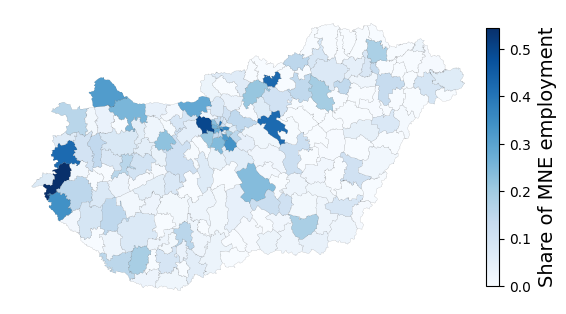

In [79]:
def plot_mnes_on_map(df, key_column, cmap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_column, cmap=cmap, edgecolor="black", linewidth=0.05, ax=ax)
    
    # colorbar
    vmin = df[key_column].min()
    vmax = df[key_column].max()
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

plot_mnes_on_map(plot_df, key_column="mne_emp_share", cmap="Blues", label_text="Share of MNE employment", fontsize=14)

correlation:  0.86782290047436


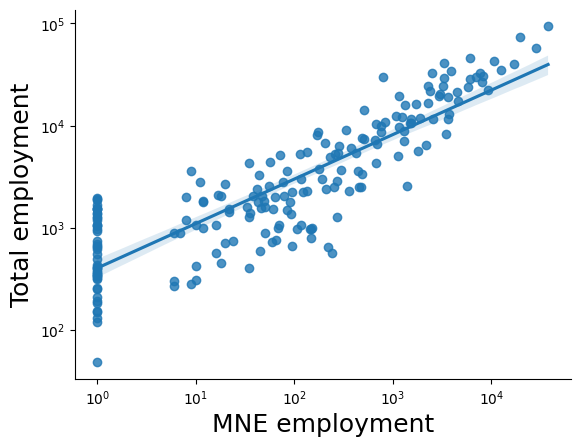

In [78]:
def scatter_mne_total(df, key_columns, labels, fontsize, ax=None):
    """function to illustrate the relationship between total EMP and MNE emp in regions"""
    
    df["log10_mne_emp"] = np.log10(df[key_columns[0]]+1)
    df["log10_total_emp"] = np.log10(df[key_columns[1]]+1)

    print("correlation: ", df["log10_mne_emp"].corr(df["log10_total_emp"]))

    if ax is None:
        ax = plt.gca()
    
    #ax.scatter(df[key_columns[0]], df[key_columns[1]], s=120, alpha=0.8)
    #ax.loglog()
    sns.regplot(data=df, x="log10_mne_emp", y="log10_total_emp", ax=ax)
    ax.set_xlabel(labels[0], size=fontsize)
    ax.set_ylabel(labels[1], size=fontsize)
    ax.set_yticks([2, 3, 4, 5])
    ax.set_yticklabels([r'$10^2$', r'$10^3$', r'$10^4$', r'$10^5$'])
    ax.set_xticks([0, 1, 2, 3, 4])
    ax.set_xticklabels([r'$10^0$', r'$10^1$', r'$10^2$', r'$10^3$', r'$10^4$'])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

scatter_mne_total(plot_df, key_columns=["mne_emp", "total_emp"], labels=["MNE employment", "Total employment"], fontsize=18)

In [ ]:
# share of MNE employment
# correlation between MNE employment and total employment
# MNE employment across sectors

# same for nr firms

# MNE employment for 1.000 people
# MNE emp for 1.000 people across industries

In [80]:
# MNEs by 2 digit NACE codes -- better for visualization
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

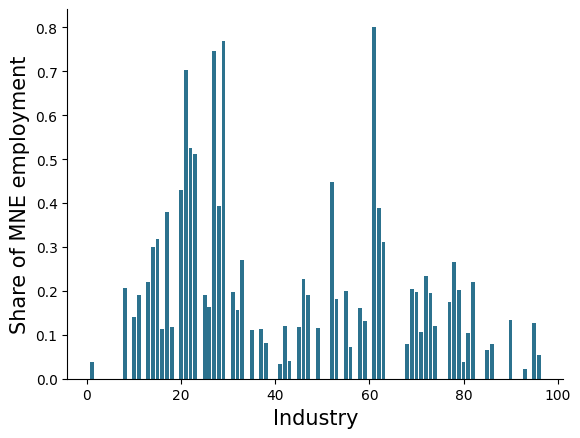

In [83]:
def plot_mne_per_industry(df, ind_column, key_column, cmap, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_column], df[key_column], color=cmap)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

plot_mne_per_industry(
    mne_ind_table,
    ind_column="nace2d",
    key_column="share_mne_emp",
    cmap="#2C728EFF",
    ylabel_text="Share of MNE employment",
    xlabel_text="Industry",
    fontsize=15
)

In [ ]:
# overlay w/ employment in general -- but it to the background w/ different color?

In [ ]:
fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])


**Figure 2 - coagglomeration, IO connections, labor flow**

In [26]:
# load data
df3 = pd.read_csv(f"../data/oc10_2023_sep/oc_mdf3_{region_level}_{year}_based.csv", sep=";")

In [33]:
def z_score(values):
    new_values = (values - np.mean(values)) / (np.max(values) - np.min(values))
    return new_values

In [36]:
# variables manipulation
df3["coagg_stand"] = z_score(df3["egk_coagg"])
df3["io_stand"] = z_score(df3["io_norm"])
df3["lab_stand"] = z_score(df3["sr_norm"])

# clear setting
columns_to_consider = ["coagg_porter", "coagg_porter_mne", "coagg_porter_local", "io_stand", "lab_stand"]
df3 = df3.dropna(subset=columns_to_consider)

In [38]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [41]:
# matrix_represantation(df3, key_columns=["ind1", "ind2", "coagg_stand"], sort_matrix=False, heatmap=True, fontsize=25, title_text="EGK coagglomeration", cmap="Blues")

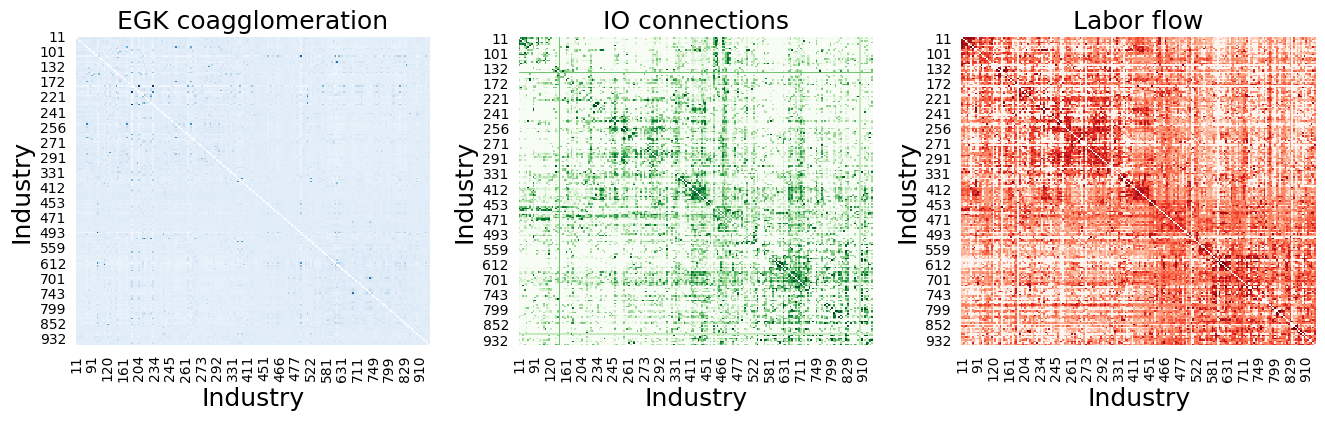

In [42]:
fig, ax = plt.subplots(1,3, figsize=(16,4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.25)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="EGK coagglomeration",
    cmap="Blues",
    ax=ax[0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "lab_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[2]
)

In [43]:
# add kde plots below the matrix row
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [69]:
# density_plot(df3, key_column="coagg_stand", colorway = "#2C728EFF", xlabel_text="EGK coagglomeration", fontsize=15)

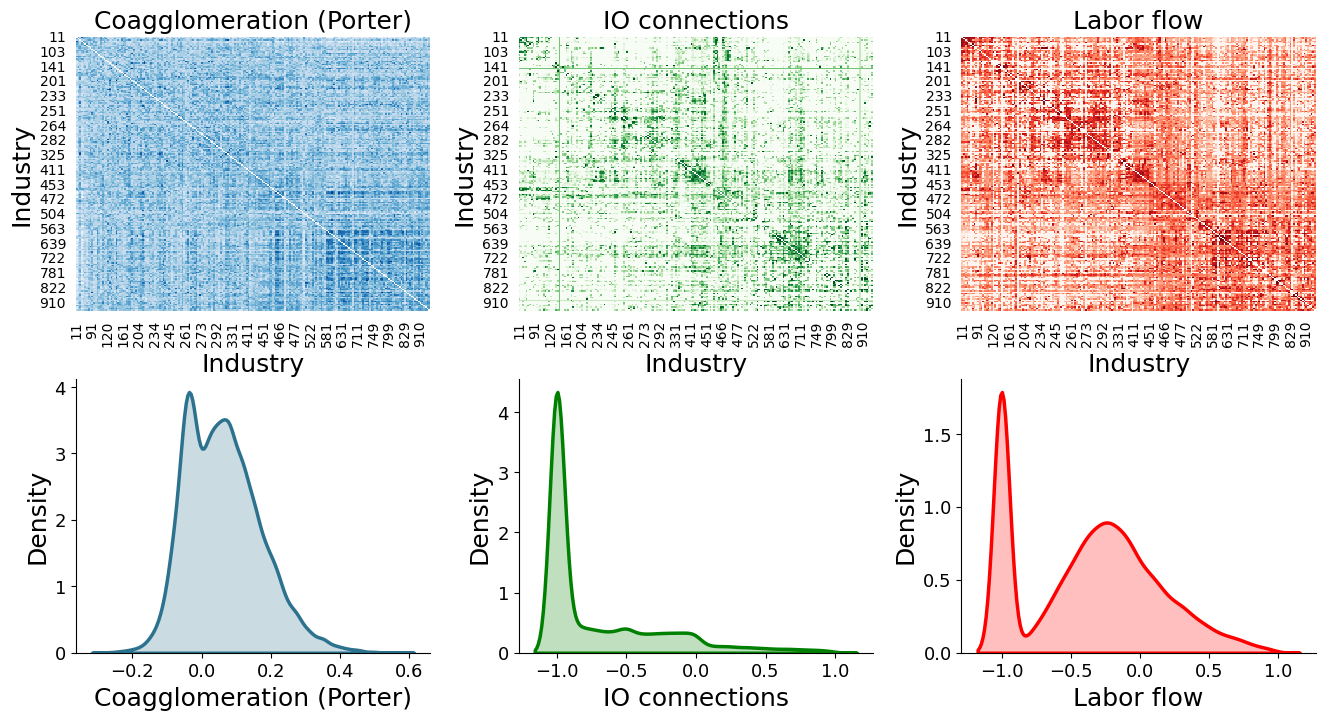

In [52]:
fig, ax = plt.subplots(2,3, figsize=(16,8))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

matrix_represantation(
    df3,
    #key_columns=["ind1", "ind2", "egk_coagg"],
    key_columns=["ind1", "ind2", "coagg_porter"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Coagglomeration (Porter)",
    cmap="Blues",
    ax=ax[0,0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[0,1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "sr_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[0,2]
)

density_plot(
    df3,
    #key_column="egk_coagg",
    key_column="coagg_porter",
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (Porter)",
    fontsize=18,
    ax=ax[1,0]
)

density_plot(
    df3,
    key_column="io_norm",
    colorway="Green",
    xlabel_text="IO connections",
    fontsize=18,
    ax=ax[1,1]
)

density_plot(
    df3,
    key_column="sr_norm",
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=18,
    ax=ax[1,2]
)


**Figure 3 - coagglomeration, foreign, domestic, foreign x domestic**

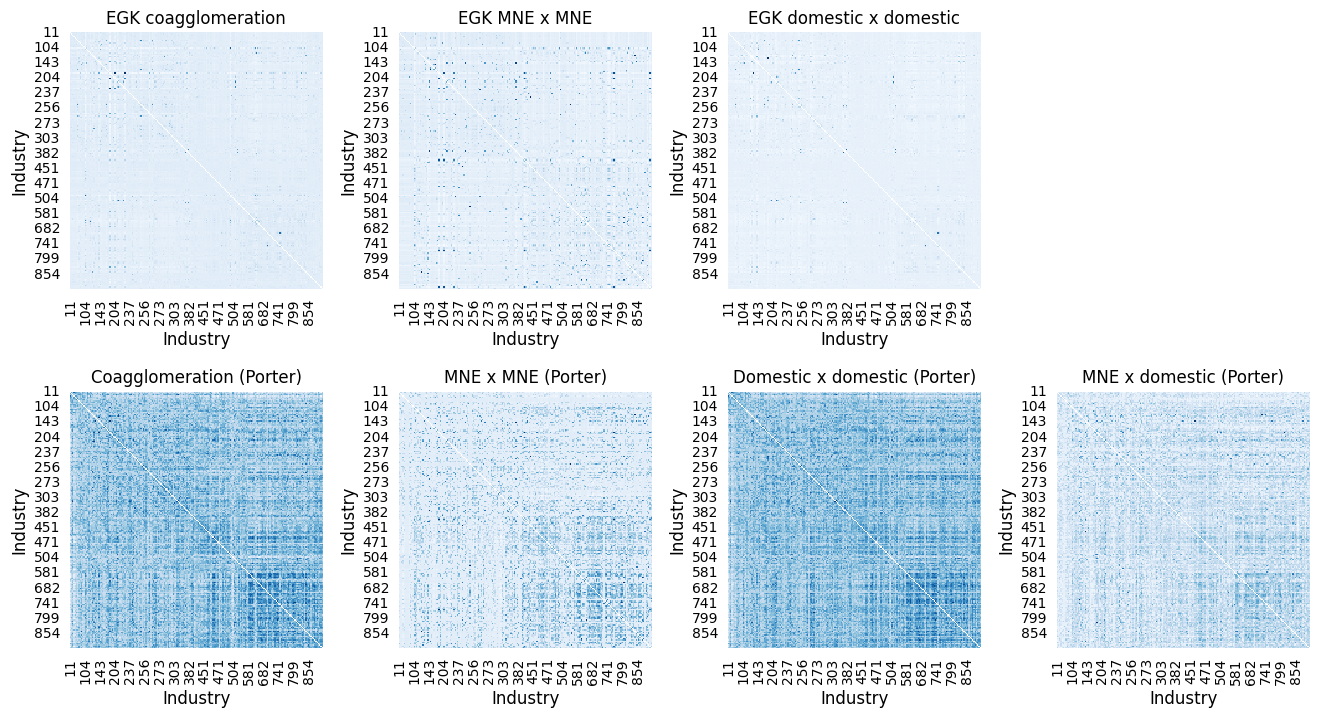

In [76]:
# separate coagglomeration / MNE / domestic / MNE x domestic matrix
fig, ax = plt.subplots(2,4, figsize=(16,8))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "egk_coagg"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="EGK coagglomeration",
    cmap="Blues",
    ax=ax[0,0]
)
matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "egk_coagg_mne"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="EGK MNE x MNE",
    cmap="Blues",
    ax=ax[0,1]
)
matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "egk_coagg_local"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="EGK domestic x domestic",
    cmap="Blues",
    ax=ax[0,2]
)
ax[0,3].axis('off')

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_porter"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="Coagglomeration (Porter)",
    cmap="Blues",
    ax=ax[1,0]
)
matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_porter_mne"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="MNE x MNE (Porter)",
    cmap="Blues",
    ax=ax[1,1]
)
matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_porter_local"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="Domestic x domestic (Porter)",
    cmap="Blues",
    ax=ax[1,2]
)
matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_porter_mne_local"],
    sort_matrix=False,
    heatmap=True,
    fontsize=12,
    title_text="MNE x domestic (Porter)",
    cmap="Blues",
    ax=ax[1,3]
)


In [3]:
# coagg / IO / SR matrix visuals
el1 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_oc.csv", sep=";")

def norm01(values):
    new_values = (values - min(values)) / (max(values) - min(values))
    return new_values

def z_score(values):
    new_values = (values - np.mean(values)) / (max(values) - min(values))
    return new_values

In [4]:
# variables manipulation
el1["egk_coagg_norm"] = norm01(el1["egk_coagg"])
el1["egk_coagg_z"] = z_score(el1["egk_coagg"])

el1["log_undir_value"] = np.log10(el1["undir_value"])
el1.replace([np.inf, -np.inf], 0, inplace=True)

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
def mpp_matrix(df, key_cols, sort_matrix, heatmap, fontsize, cmap, ax=None):
    """matrix visualization"""
    table = df[key_cols]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_cols]
    table = pd.concat([table, table2])

    table = pd.pivot_table(table,
        values=key_cols[2],
        index=key_cols[0],
        columns=key_cols[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
     
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

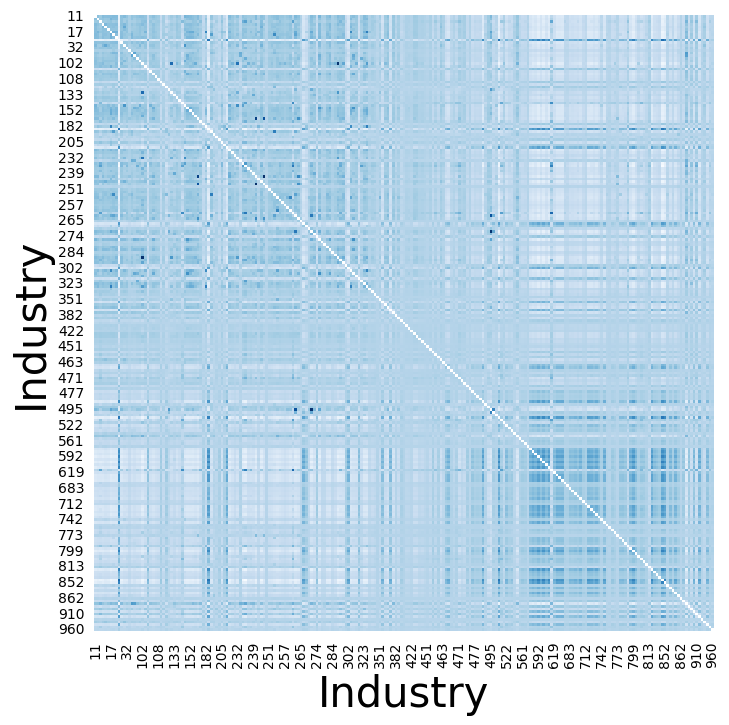

In [8]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "egk_coagg_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Blues", ax=None)

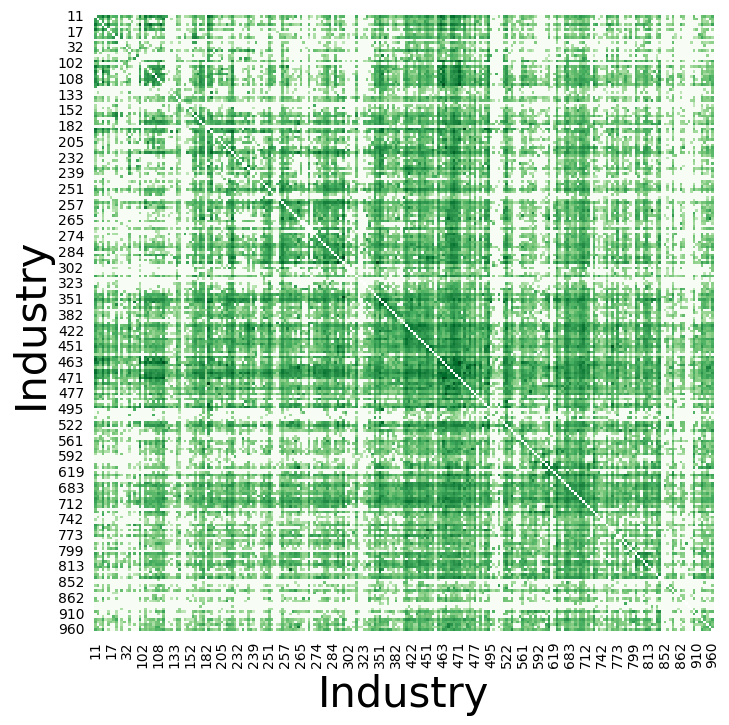

In [9]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "log_undir_value"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Greens", ax=None)

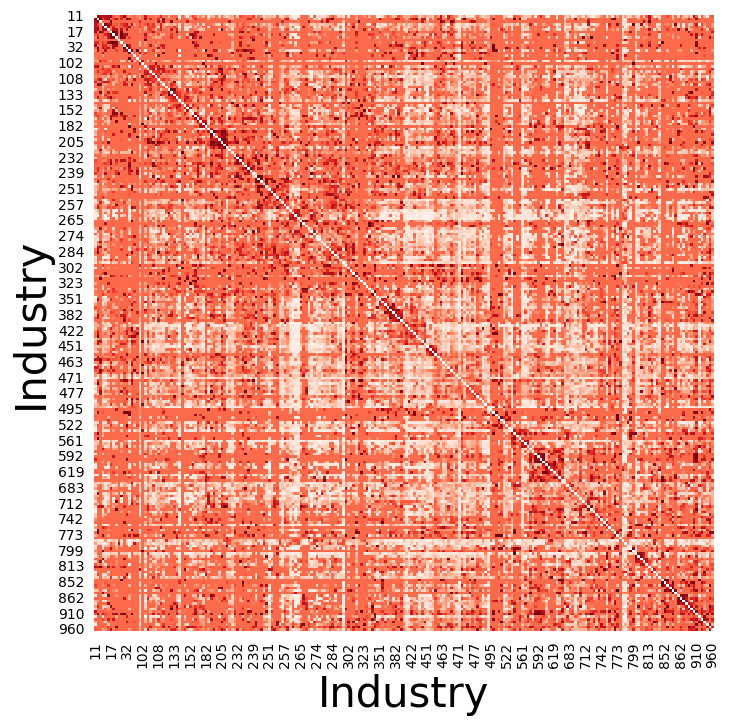

In [10]:
fig, ax = plt.subplots(1,1, figsize=(8,8)) 
mpp_matrix(el1, key_cols=["ind1", "ind2", "hun_sr_norm"], sort_matrix=False, heatmap=True, fontsize=30, cmap="Reds", ax=None)


### Constructing coagglomeration measures from Mcp


In [10]:
# industry-region data with RCAs
indreg = pd.read_csv("../data/oc_2022_november/indreg_2018_2020_megye.csv", sep=";")
indreg["rca01"] = (indreg["rca18"] >= 1).astype(int)

In [23]:
def mcp_matrix_plot(df, key_cols, transpose, heatmap, labels, size, ax=None):
    """ Mcp matrix visualization """
    table = df[key_cols]
    
    table = pd.pivot_table(table,
        values=key_cols[2],
        index=[key_cols[1]],
        columns=[key_cols[0]],
        aggfunc=np.sum,
        margins=True,
        margins_name='total')
    
    if transpose==True:
        table = table.transpose()

    table = table\
        .sort_values(by=["total"], ascending=False, axis=0)\
        .sort_values(by=["total"], ascending=False, axis=1)

    table = table.drop(["total"], axis=1).drop(["total"], axis=0)

    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap="Blues", ax=ax)
        #ax.set_title("RCA 0/1", size=size)
        ax.set_xlabel(labels[0], size=size)
        ax.set_ylabel(labels[1], size=size)
        ax.set_xticklabels("")
        ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

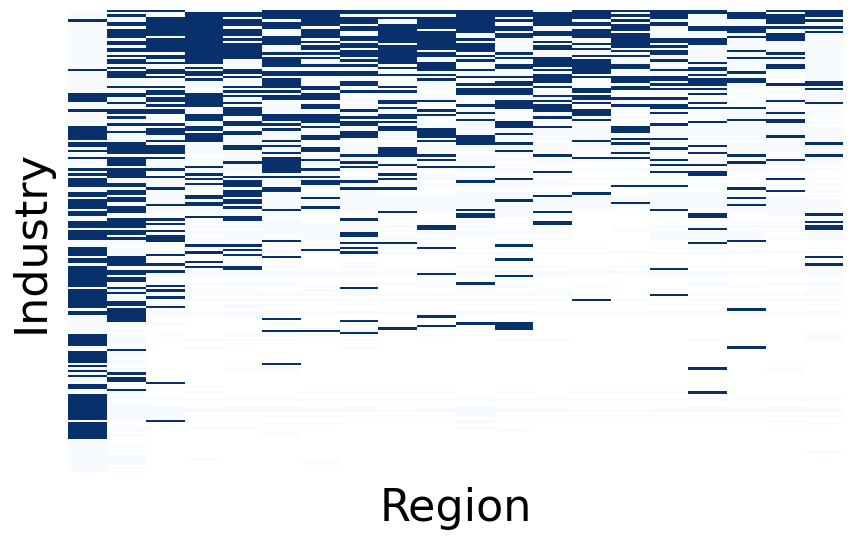

In [29]:
fig, ax = plt.subplots(1,1, figsize=(10,6))
mcp_matrix_plot(indreg, key_cols=["reg", "ind", "rca01"], transpose=False, labels=["Region", "Industry"], size=32, heatmap=True, ax=ax)

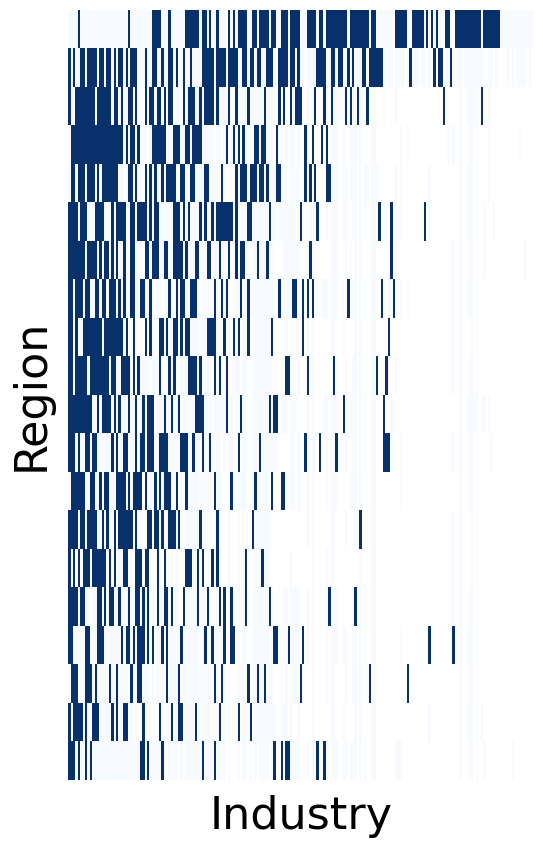

In [30]:
fig, ax = plt.subplots(1,1, figsize=(6,10))
mcp_matrix_plot(indreg, key_cols=["reg", "ind", "rca01"], transpose=True, labels=["Industry", "Region"], size=32, heatmap=True)

### correlation of resulted coagglomeration measures

In [3]:
# regression dataframe
mdf3 = pd.read_csv("../data/oc_2023_march_labor/m01_data_output_OC.csv", sep=";")

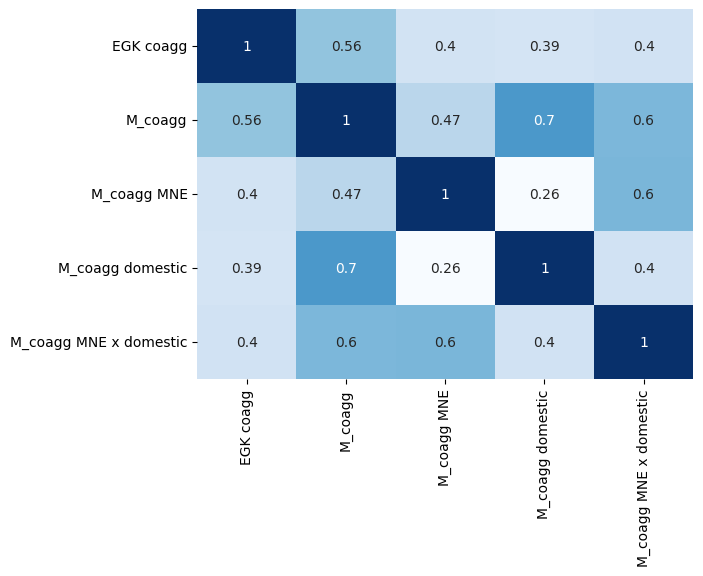

In [13]:
def correlation_matrix(data, key_cols, heatmap, labels, ax=None):
    corr_df = data[key_cols].corr()

    if heatmap==False:
        return corr_df
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(corr_df, cbar=False, annot=True, cmap="Blues", ax=ax)
        ax.set_xticklabels(labels)
        ax.set_yticklabels(labels)

labels = ["EGK coagg", "M_coagg", "M_coagg MNE", "M_coagg domestic", "M_coagg MNE x domestic"]
correlation_matrix(mdf3, key_cols=["egk_coagg", "coagg", "coagg_mne", "coagg_local", "coagg_mne_local"], heatmap=True, labels=labels)

### MNE visuals

In [18]:
# parameters
region_level = "megye"
# region_level = "jaras"

In [19]:
# 1 -- distribution of MNEs
mne_df = pd.read_csv("../data/oc_2022_november/mne_share_nace3d_" + str(region_level) +".csv", sep=";")
region_gdf = gpd.read_file("../data/shape_files/" + str(region_level) + "_shape.geojson")
key_table = pd.read_csv("../data/oc_2022_november/region_codes.csv", sep=";")

In [21]:
# join region codes to shape
key_table = key_table.filter(regex=region_level).drop_duplicates()
key_column = str(region_level) + "_nev"
plot_df = pd.merge(
    region_gdf,
    key_table,
    left_on="region_name",
    right_on=key_column,
    how="left"
)

In [23]:
# aggregate MNE data
group_col = str(region_level) + "_kod"

region_mne_agg_table = mne_df.groupby(group_col)\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

region_mne_agg_table["mne_firm_share"] = region_mne_agg_table["nr_mnes"] / region_mne_agg_table["nr_firms"]
region_mne_agg_table["mne_emp_share"] = region_mne_agg_table["mne_emp"] / region_mne_agg_table["total_emp"]

In [41]:
# aggregate MNE data to manufacturing only?
manuf_mne_df = mne_df[(mne_df["nace3d"]>=100) & (mne_df["nace3d"]<350)]

# need to go back to check the limits for services
serv_mne_df = mne_df[mne_df["nace3d"]<960]

,megye_kod,nace3d,mne_count,nr_firms,total_emp,emp_max_hozz,mne_emp,mne_emp_share,mne_dom_25,mne_dom_50,mne_dom_75
10,1,101,3,66,2738,0.117969,114,0.041636,0,0,0
11,1,103,4,33,769,0.318596,426,0.553966,1,1,0
12,1,105,2,17,1033,0.446273,499,0.483059,1,0,0
13,1,106,0,9,253,0.517787,0,0.000000,0,0,0
14,1,107,40,270,3884,0.090371,1257,0.323635,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2386,20,310,1,43,1353,0.404287,144,0.106430,0,0,0
2387,20,323,0,5,27,0.407407,0,0.000000,0,0,0
2388,20,325,0,10,43,0.232558,0,0.000000,0,0,0
2389,20,331,0,22,114,0.228070,0,0.000000,0,0,0


In [25]:
# merge MNE data to map
key_col = str(region_level) + "_kod"
plot_df = pd.merge(
    plot_df,
    region_mne_agg_table,
    on=key_col,
    how="left"
)

In [27]:
def plot_mnes_on_map(df, key_var, colormap, label_text, fontsize, ax=None):
    """function to create map of MNE firms in Hungary"""
    if ax is None:
        ax = plt.gca()

    # map part    
    df.plot(column=key_var, cmap=colormap, edgecolor="white", linewidth=0.15, ax=ax)
    
    # colorbar
    vmin = df[key_var].min()
    vmax = df[key_var].max()
    sm = plt.cm.ScalarMappable(cmap=colormap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = plt.colorbar(sm, fraction=0.04, pad=0.0001, shrink=0.7, ax=ax)
    cbar.ax.set_ylabel(label_text, rotation=90, size=fontsize)
    cbar.ax.get_yaxis().labelpad = 5

    ax.axis('off')

# plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=14)

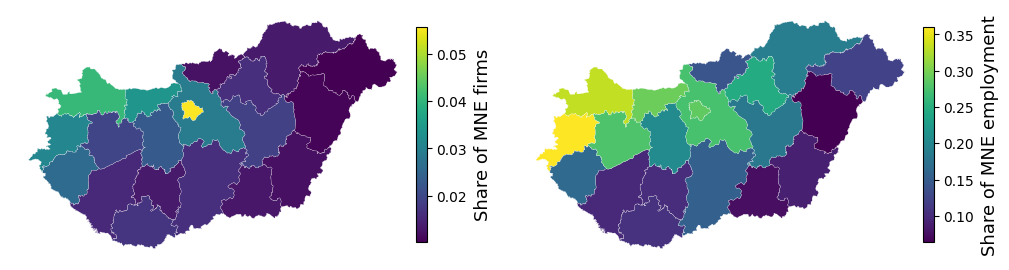

In [28]:
# grid of different plots
fig, ax = plt.subplots(1,2, figsize=(12,4))
plot_mnes_on_map(plot_df, key_var="mne_firm_share", colormap="viridis", label_text="Share of MNE firms", fontsize=13, ax=ax[0])
plot_mnes_on_map(plot_df, key_var="mne_emp_share", colormap="viridis", label_text="Share of MNE employment", fontsize=13, ax=ax[1])

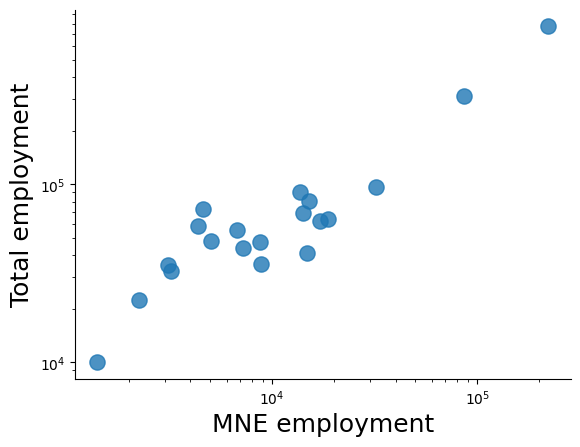

In [36]:
def scatter_mne_total(df, key_var, labels, fontsize, ax=None):
    """function to illustrate the relationship between total EMP and MNE emp in regions"""
    if ax is None:
        ax = plt.gca()
    
    ax.scatter(df[key_var[0]], df[key_var[1]], s=120, alpha=0.8)
    ax.loglog()
    ax.set_xlabel(labels[0], size=fontsize)
    ax.set_ylabel(labels[1], size=fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

scatter_mne_total(plot_df, key_var=["mne_emp", "total_emp"], labels=["MNE employment", "Total employment"], fontsize=18)

In [ ]:

scatter_mne_total(plot_df, key_var=["mne_emp", "total_emp"], labels=["MNE employment", "Total employment"], fontsize=18)

In [ ]:
log10_mne_emp

In [5]:
# MNEs per industry figure
mne_df["nace2d"] = mne_df["nace3d"] // 10
mne_ind_table = mne_df.groupby(["nace2d"])\
    .agg(
        nr_mnes = pd.NamedAgg(column="mne_count", aggfunc="sum"),
        nr_firms = pd.NamedAgg(column="nr_firms", aggfunc="sum"),
        nr_mne_emp = pd.NamedAgg(column="mne_emp", aggfunc="sum"),
        total_emp = pd.NamedAgg(column="total_emp", aggfunc="sum"),
    ).reset_index()

mne_ind_table["share_mne_firms"] = mne_ind_table["nr_mnes"] / mne_ind_table["nr_firms"]
mne_ind_table["share_mne_emp"] = mne_ind_table["nr_mne_emp"] / mne_ind_table["total_emp"]

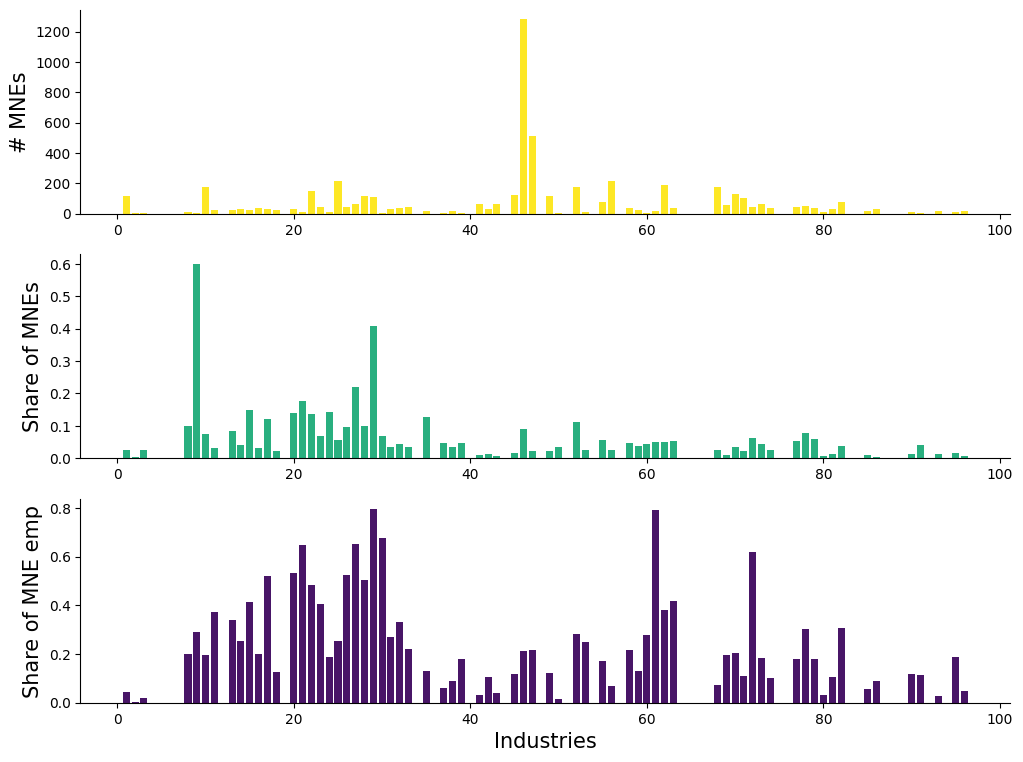

In [16]:
def plot_mne_per_industry(df, ind_col, key_col, color_code, ylabel_text, fontsize, xlabel_text=None, ax=None):
    """function to illustrate the distribution of MNEs across industries in Hungary"""
    if ax is None:
        ax = plt.gca()

    # plot
    ax.bar(df[ind_col], df[key_col], color=color_code)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(ylabel_text, size=fontsize)
    if xlabel_text is None:
        ax.set_xlabel("", size=fontsize)
    else:
        ax.set_xlabel(xlabel_text, size=fontsize)

fig = plt.figure(figsize=(12,9))
ax = [0]*3

gs = GridSpec(3,1, figure=fig)
ax[0] = fig.add_subplot(gs[0,0])
ax[1] = fig.add_subplot(gs[1,0])
ax[2] = fig.add_subplot(gs[2,0])
plot_mne_per_industry(mne_ind_table, "nace2d", "nr_mnes", color_code="#FDE725FF", ylabel_text="# MNEs", fontsize=15, ax=ax[0])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_firms", color_code="#29AF7FFF", ylabel_text="Share of MNEs", fontsize=15, ax=ax[1])
plot_mne_per_industry(mne_ind_table, "nace2d", "share_mne_emp", color_code="#481567FF", ylabel_text="Share of MNE emp", fontsize=15, xlabel_text="Industries", ax=ax[2])
